<a href="https://colab.research.google.com/github/rpujala/machine_learning/blob/main/TensorFlow_Quick_Start_for_Experts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print(tf.__version__)

2.19.0


In [ ]:
from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras import Model

In [ ]:
mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()


In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
X_train.ndim

3

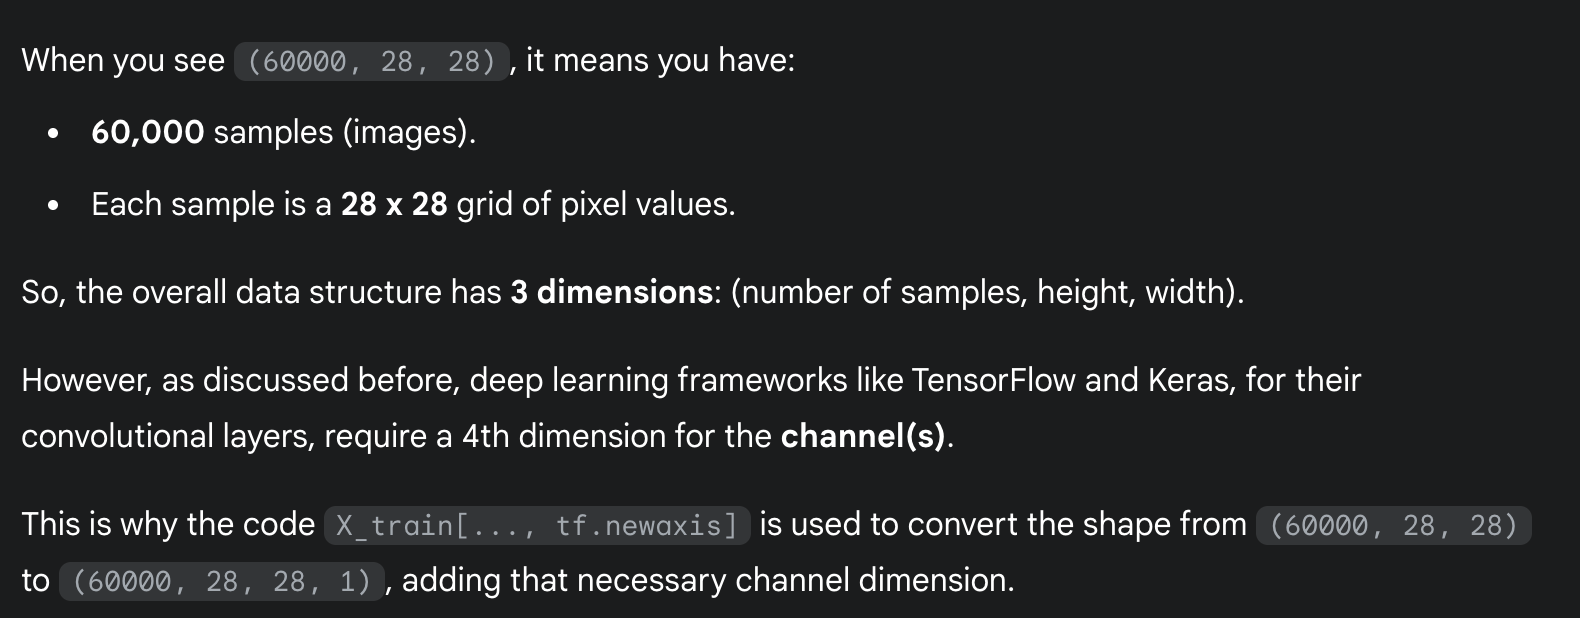

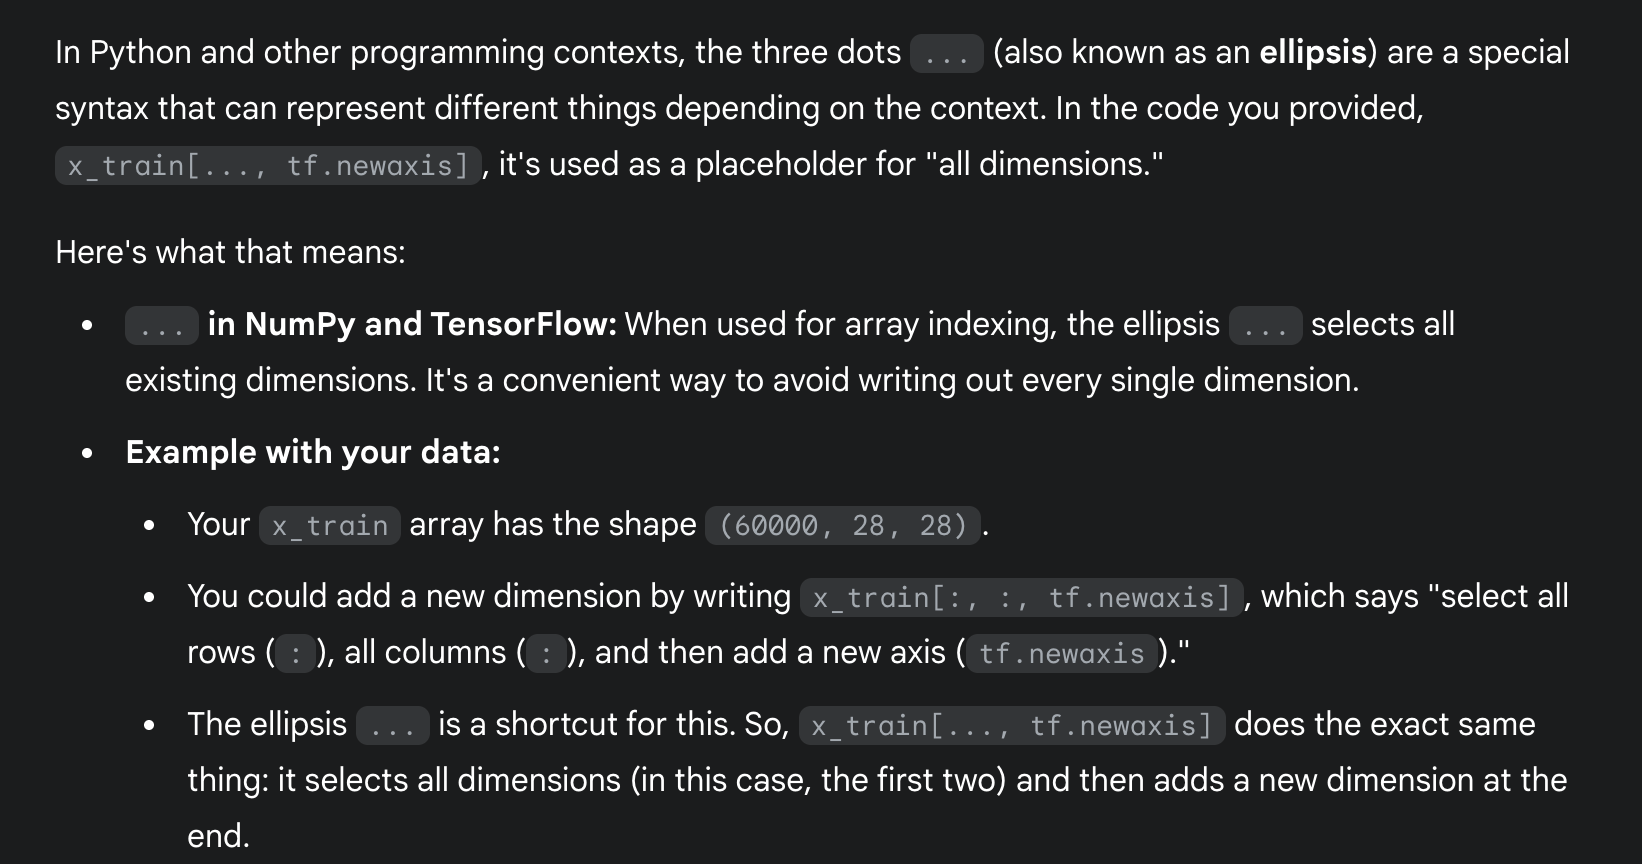

In [ ]:
# Add a channels dimension

X_train = X_train[..., tf.newaxis].astype('float32')
X_test = X_test[..., tf.newaxis].astype('float32')

#or can also write like below

X_train = X_train.reshape(60000, 28, 28, 1).astype('float32')
X_test = X_test.reshape(10000, 28, 28, 1).astype('float32')

In [ ]:
X_train.ndim

4

Use **tf.data** to batch and shuffle the dataset

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(10000).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

You create datasets in machine learning to **efficiently manage and process your data**, especially when dealing with large volumes. This is a crucial step in building a robust and scalable input pipeline for training your models.

### Key Reasons for Creating Datasets

* **Performance:** Datasets are designed for high performance. They can load and preprocess data in the background while your model is training on the GPU, preventing bottlenecks and keeping the GPU busy. This is much more efficient than loading the entire dataset into memory all at once.
* **Scalability:** A `tf.data.Dataset` can handle datasets that are too large to fit in memory. It can stream data directly from disk or a cloud storage service, allowing you to work with massive datasets that would otherwise be unmanageable.
* **Data Transformation:** Datasets provide a powerful and flexible API to perform common data transformations. You can chain various methods to easily shuffle, batch, repeat, and map preprocessing functions over your data.

    * `.shuffle()`: Randomizes the order of the data to improve model generalization.
    * `.batch()`: Groups elements into batches for training. This is essential for modern deep learning, as models are trained on batches of data rather than one sample at a time.
    * `.map()`: Applies a function to each element of the dataset, which is perfect for tasks like image resizing, normalization, or one-hot encoding.
* **Standardization:** Using a `tf.data.Dataset` creates a standardized input format for TensorFlow models, whether they are built with Keras or a custom training loop. This makes your code more readable, reusable, and easier to debug.

In short, creating datasets provides a structured, high-performance, and scalable way to feed data to your models, which is a key best practice in deep learning.

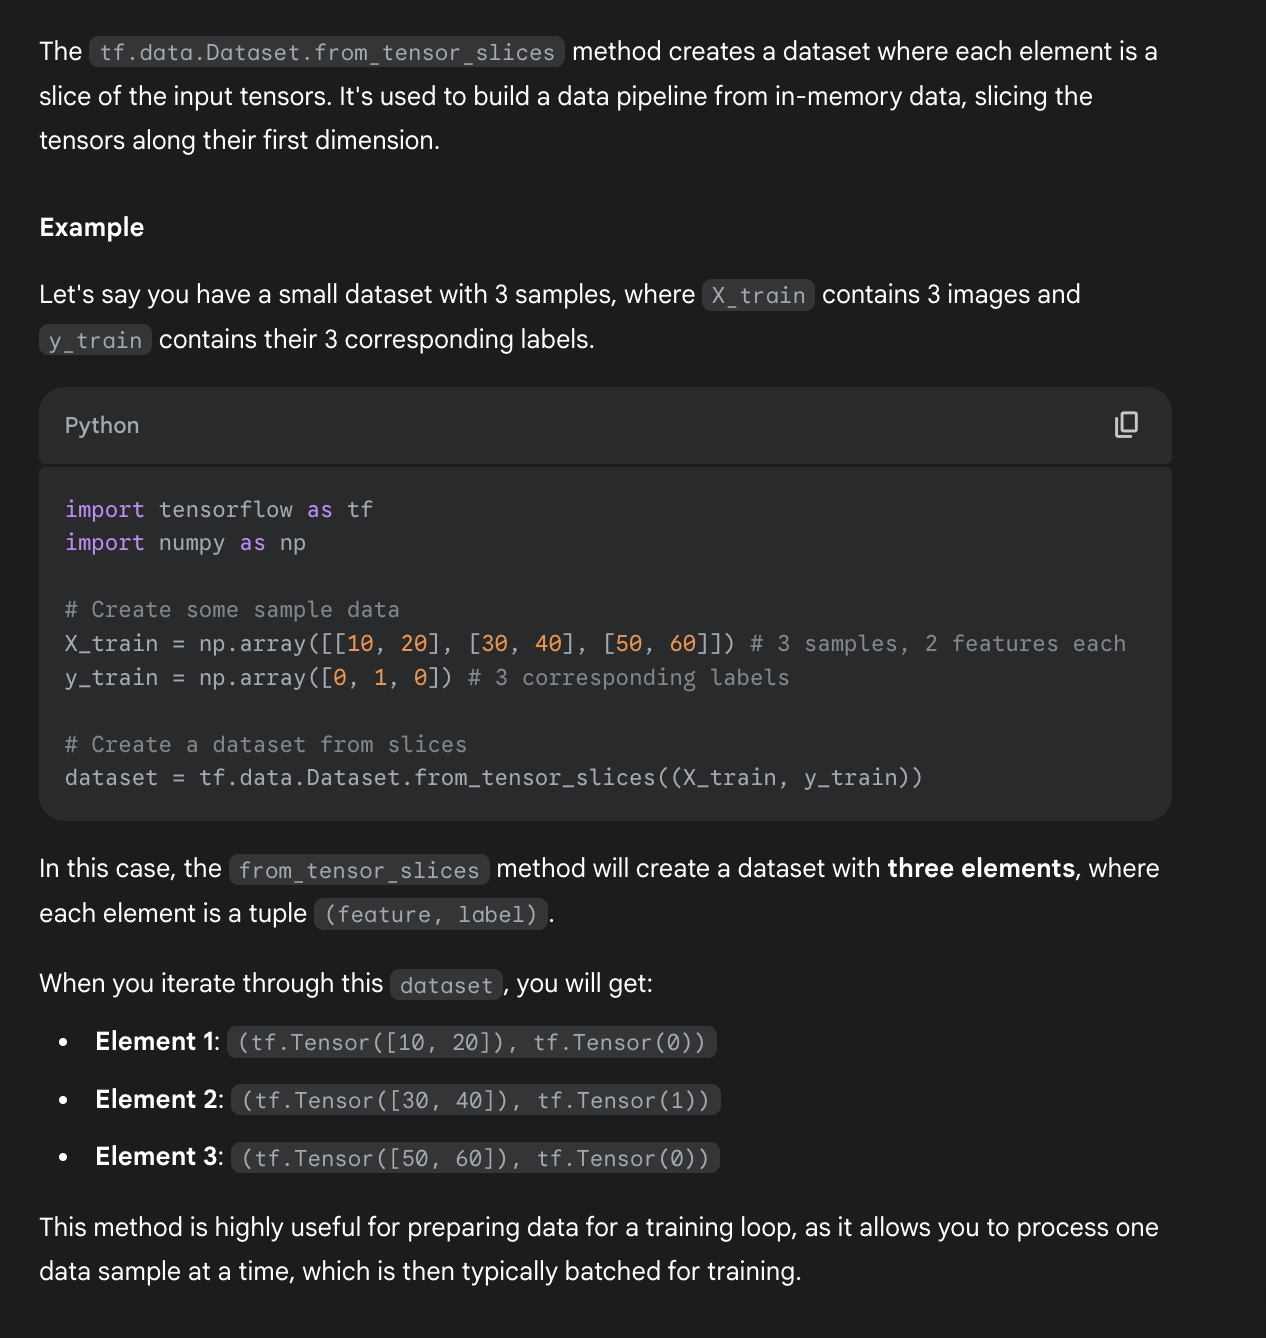

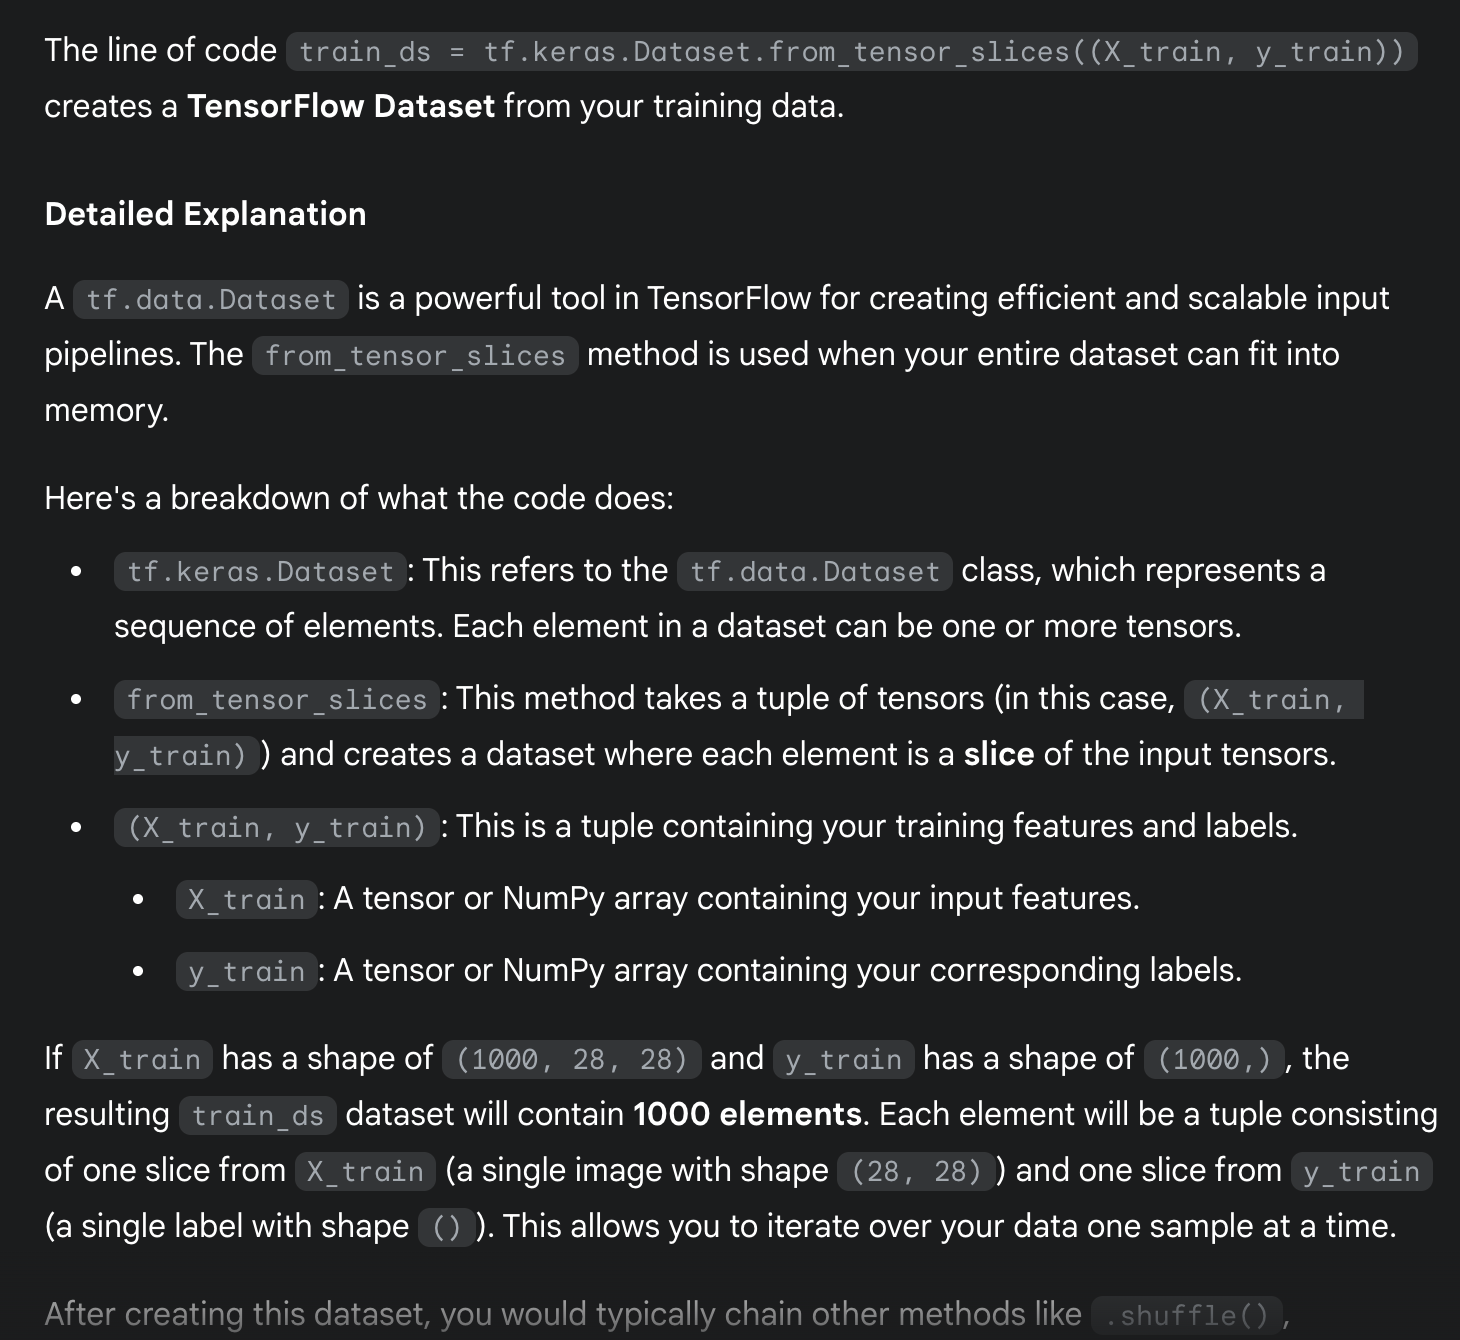

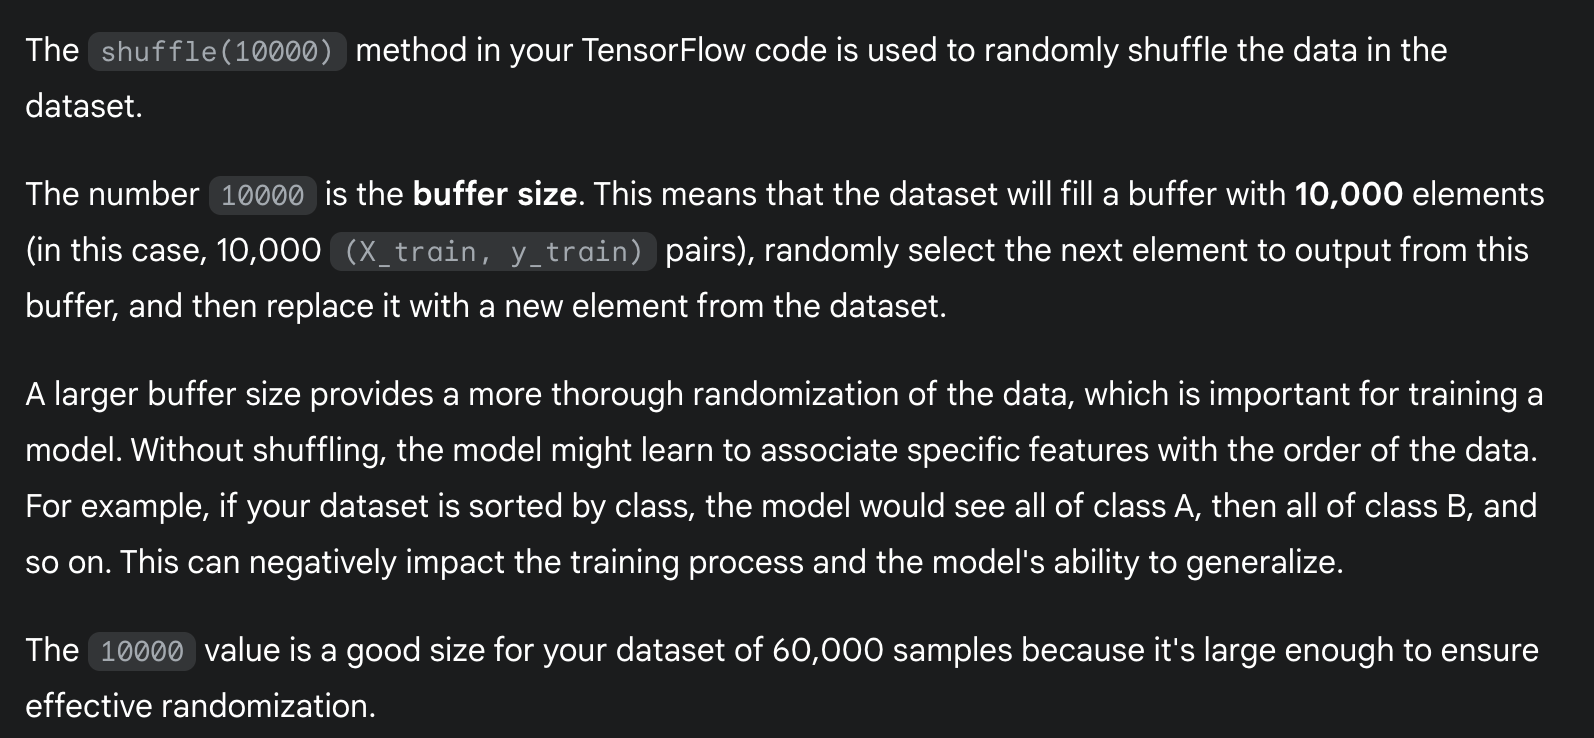

Build the **tf.keras** model using the Keras **model subclassing API**.

This approach is an alternative to the Sequential and Functional APIs. It gives you maximum flexibility to define complex architectures with custom logic in the call method.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, Flatten, Dense
from tensorflow.keras import Model

class MyModel(Model):
  #In the line class MyModel(Model):, y
  #ou are defining a new class named MyModel that inherits from the tf.keras.
  #Model class. This is the standard way to create a custom model in Keras using model subclassing.

  def __init__(self):
    super().__init__()

    self.conv1 = Conv2D(32, 3, activation='relu')
    self.conv2 = Conv2D(16, 3, activation='relu')
    self.flatten = Flatten() # always flatten before passing to dense layers
    self.d1 = Dense(128, activation='relu')
    self.d2 = Dense(10)

# Forward method
  def call(self, x):
    x =self.conv1(x)
    x =self.conv2(x)
    x = self.flatten(x)
    x = self.d1(x)
    return self.d2(x)

# Create an instance of the model
model = MyModel()

dummy = tf.ones((1, 28, 28, 1))
model(dummy)

model.summary()

<MyModel name=my_model_5, built=False>

b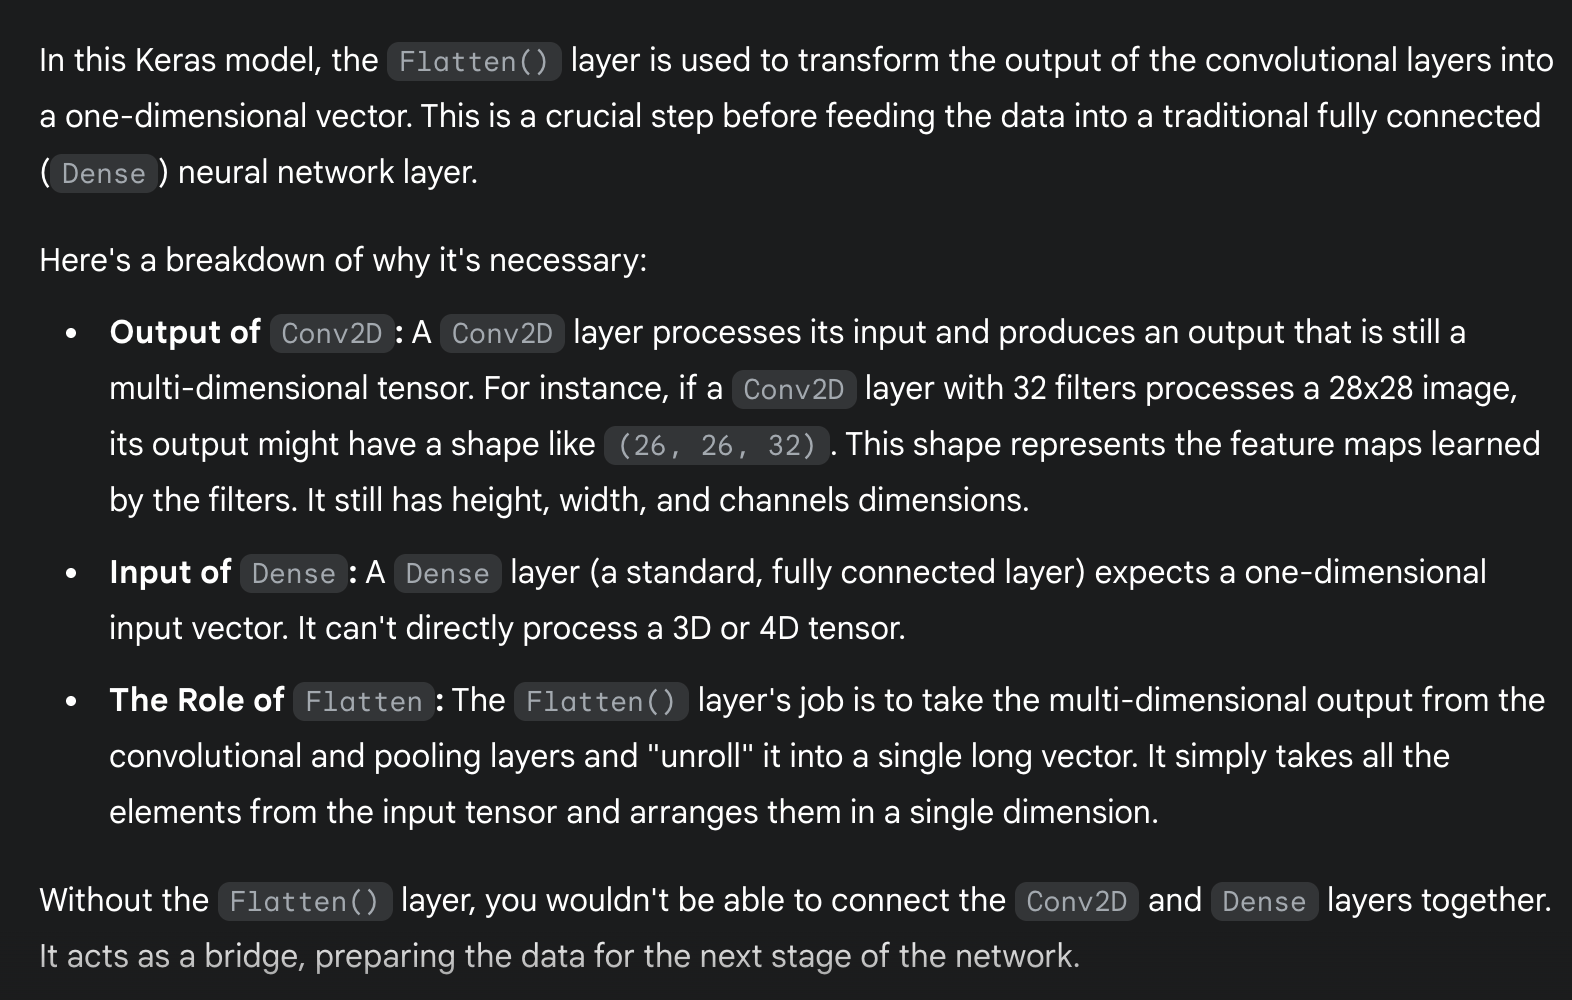

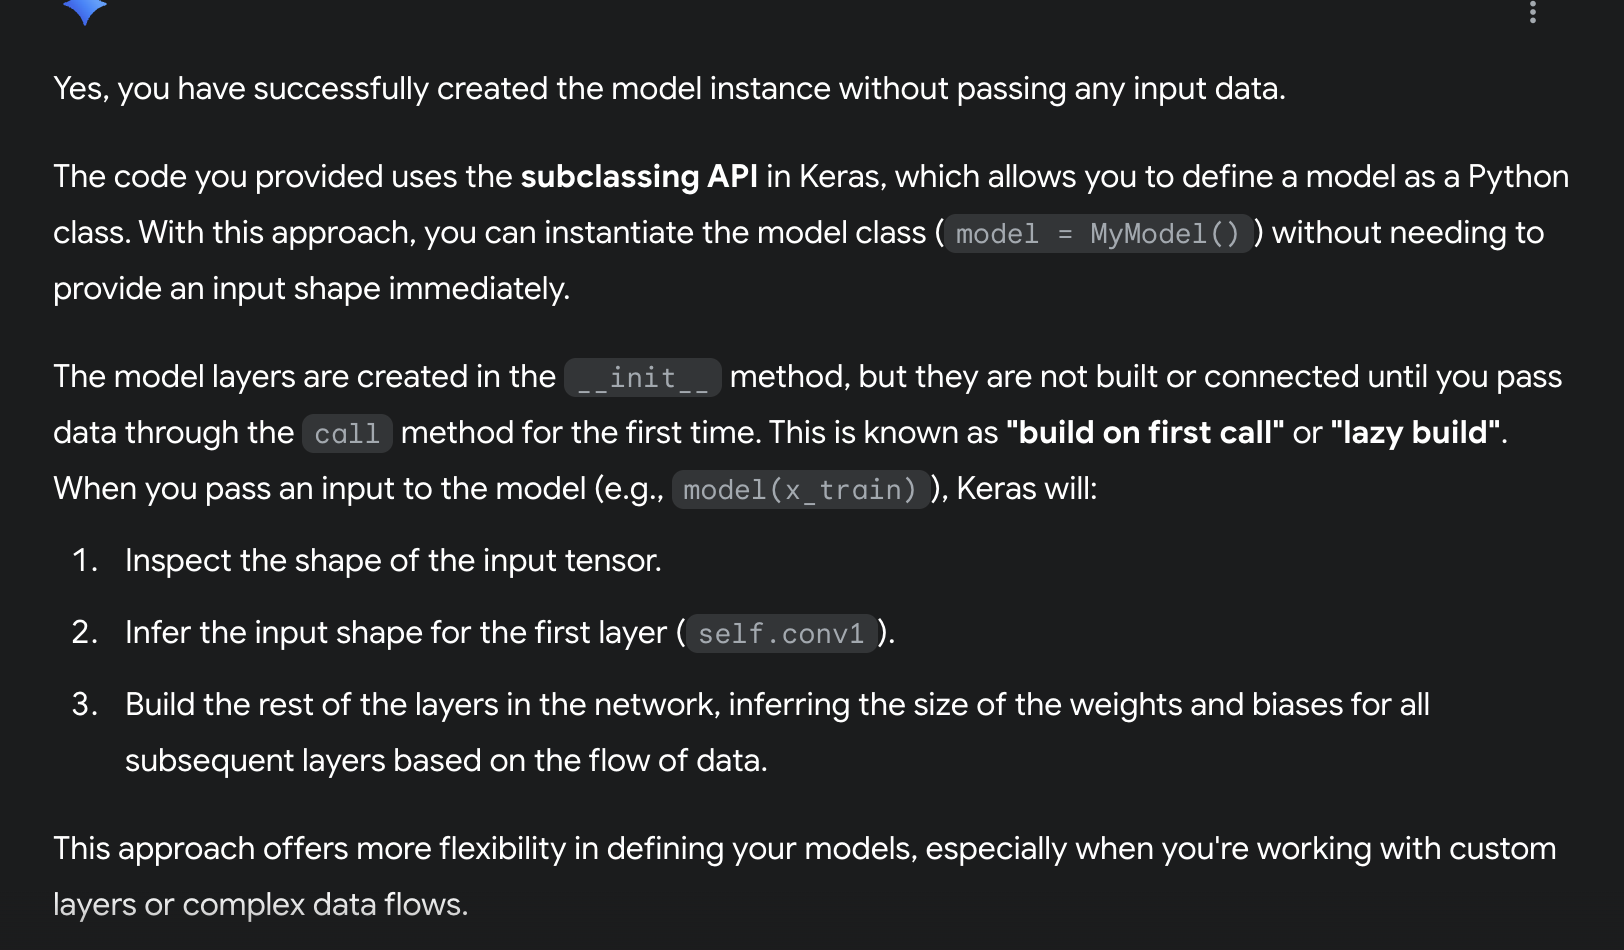

Choose an optimizer and loss function for the training

In [ ]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

optimizer = tf.keras.optimizers.Adam()

Select metrics to measure the loss and the accuracy of the model. These metrics accumulate the values over epochs and then print the overall result

In [ ]:
train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')

test_loss = tf.keras.metrics.Mean(name='test_loss')
test_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='test_accuracy')

Use **tf.GradientTape** to train the model

In [ ]:
@tf.function

def train_step(images, labels):
  with tf.GradientTape() as tape:
    # training=True is only needed if there are layers with different behaviour during training versus predictions (eg: dropout)

    predictions = model(images, training=True)
    loss = loss_object(labels, predictions)

  gradients = tape.gradient(loss, model.trainable_variables) # dx / dy
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

  train_loss(loss)
  train_accuracy(labels, predictions)

Test the model

In [ ]:
@tf.function

def test_step(images, labels):
  # training=False is only needed if there are layers with different
  # behaviour during training vs predictions (ex: Dropout)

  predictions = model(images, training=False)
  t_loss = loss_object(labels, predictions)

  test_loss(t_loss)
  test_accuracy(labels, predictions)

In [ ]:
epochs = 5

for epoch in range(epochs):
  # Rest the metrics at the start of the next epoch

  train_loss.reset_state()
  test_loss.reset_state()
  train_accuracy.reset_state()
  test_accuracy.reset_state()

  for images, labels in train_ds:
    train_step(images, labels)

  for test_images, test_labels in test_ds:
    test_step(test_images, test_labels)

  print(
      f"Epoch: {epoch + 1}",
      f"Training Loss: {train_loss.result():.2f}",
      f"Training Accuracy: {train_accuracy.result():.2f}",
      f"Test Loss: {test_loss.result():.2f}",
      f"Test Accuracy: {test_accuracy.result():.2f}"
  )

Epoch: 1 Training Loss: 0.14 Training Accuracy: 0.96 Test Loss: 0.06 Test Accuracy: 0.98
Epoch: 2 Training Loss: 0.04 Training Accuracy: 0.99 Test Loss: 0.06 Test Accuracy: 0.98
Epoch: 3 Training Loss: 0.02 Training Accuracy: 0.99 Test Loss: 0.05 Test Accuracy: 0.98
Epoch: 4 Training Loss: 0.01 Training Accuracy: 1.00 Test Loss: 0.06 Test Accuracy: 0.98


KeyboardInterrupt: 

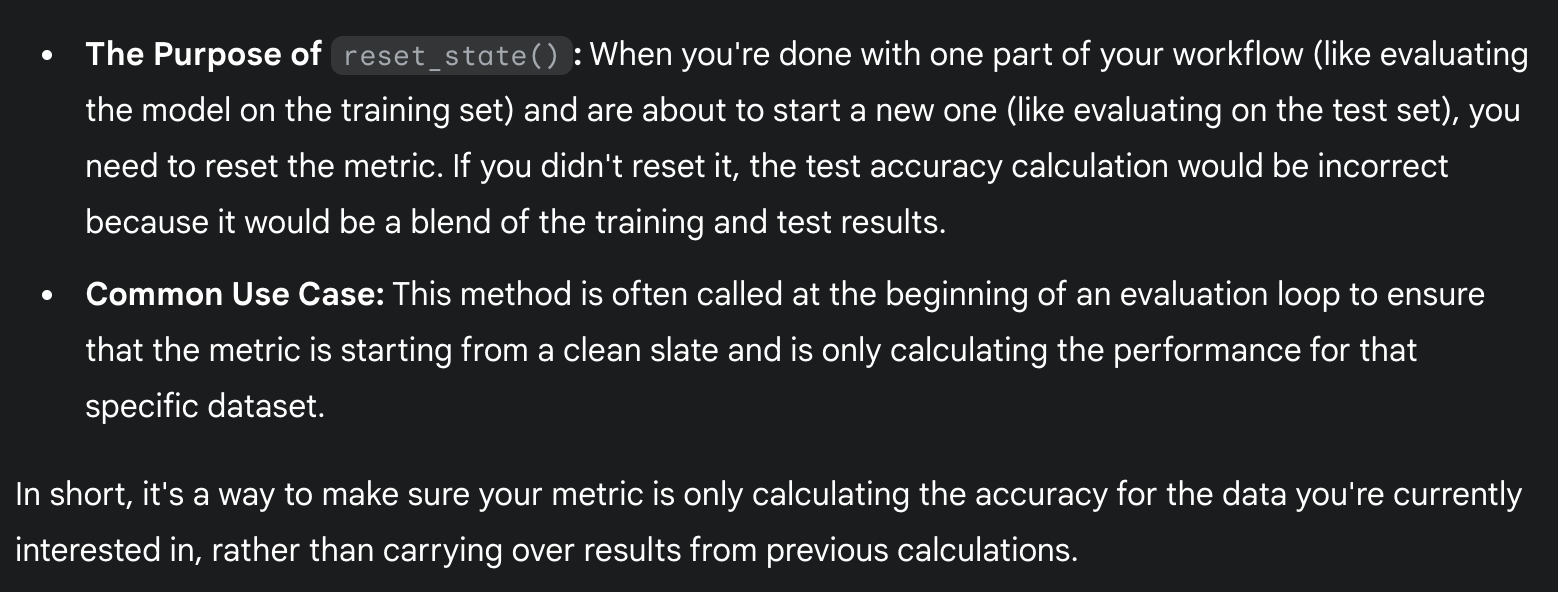

* Epoch: 1 Training Loss: 0.27 Test loss: 0.11 Training Acc: 0.93 Test Acc: 0.97
* Epoch: 2 Training Loss: 0.09 Test loss: 0.07 Training Acc: 0.97 Test Acc: 0.98
* Epoch: 3 Training Loss: 0.06 Test loss: 0.05 Training Acc: 0.98 Test Acc: 0.98
* Epoch: 4 Training Loss: 0.04 Test loss: 0.04 Training Acc: 0.99 Test Acc: 0.98
* Epoch: 5 Training Loss: 0.03 Test loss: 0.05 Training Acc: 0.99 Test Acc: 0.98
​

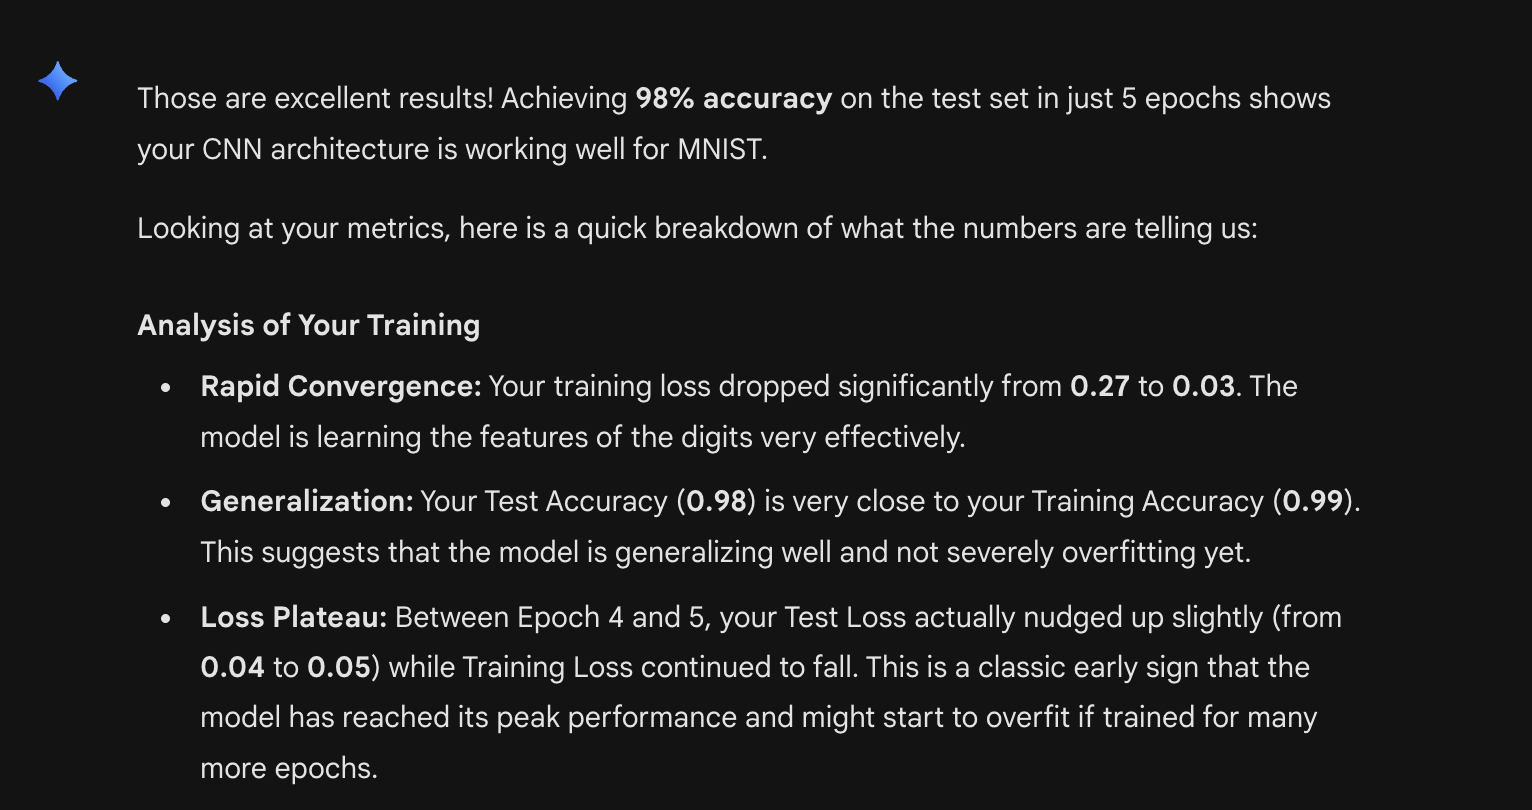

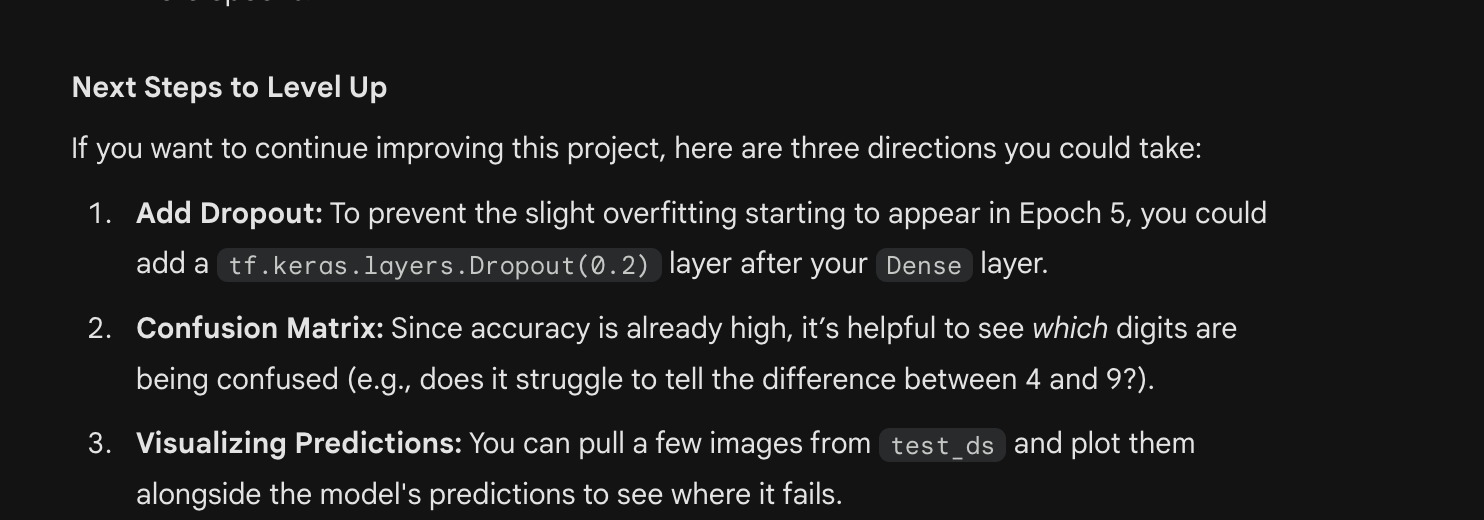

You can also use callbacks like below in the custom function

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'cc_model_12_sep.keras',
        monitor='val_los',
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        min_delta=0.001,
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

callbacks_list = tf.keras.callbacks.CallbackList(
    callbacks,
    add_history=True,
    model=model
)


epochs = 5

# 3. Trigger the start of training
callbacks_list.on_train_begin()

for epoch in range(epochs):
    # Trigger epoch begin
    callbacks_list.on_epoch_begin(epoch)

    train_loss.reset_state()
    test_loss.reset_state()
    train_acc.reset_state()
    test_acc.reset_state()

    # Train Loop
    for step, (images, label) in enumerate(train_ds):
        callbacks_list.on_train_batch_begin(step)

        train_step(images, label)

        # Optional: Pass batch logs if your callbacks require batch-level metrics
        batch_logs = {'loss': train_loss.result().numpy()}
        callbacks_list.on_train_batch_end(step, logs=batch_logs)

    # Test Loop (Validation)
    for step, (images, label) in enumerate(test_ds):
        test_step(images, label)

    # 4. Gather metrics into a logs dictionary for the epoch callbacks
    # CRITICAL: Keys must match the 'monitor' strings in your callbacks (e.g., 'test_loss')
    epoch_logs = {
        'loss': train_loss.result().numpy(),
        'accuracy': train_acc.result().numpy(),
        'test_loss': test_loss.result().numpy(),
        'test_accuracy': test_acc.result().numpy()
    }

    # Trigger epoch end (EarlyStopping/ModelCheckpoint read epoch_logs here)
    callbacks_list.on_epoch_end(epoch, logs=epoch_logs)